# NGS QC Dashboard

## Purpose

This notebook summarizes sequencing quality-control metrics generated from FastQC and MultiQC outputs.

The goal is to demonstrate a reproducible NGS QC workflow using public FASTQ test data, command-line QC tools, and Python-based dashboard-style reporting.

The workflow includes FastQC analysis, MultiQC aggregation, sample-level QC metric parsing, summary table generation, visualization, and interpretation.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

project_dir = Path("..")
results_dir = project_dir / "results"
multiqc_data_dir = results_dir / "multiqc" / "multiqc_data"

summary_tables_dir = results_dir / "summary_tables"
figures_dir = results_dir / "figures"

summary_tables_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

general_stats_path = multiqc_data_dir / "multiqc_general_stats.txt"
fastqc_status_path = multiqc_data_dir / "fastqc-status-check-heatmap.txt"

general_stats_path, fastqc_status_path

(WindowsPath('../results/multiqc/multiqc_data/multiqc_general_stats.txt'),
 WindowsPath('../results/multiqc/multiqc_data/fastqc-status-check-heatmap.txt'))

In [2]:
qc_stats = pd.read_csv(general_stats_path, sep="\t")
qc_stats.head()

,Sample,fastqc-percent_duplicates,fastqc-percent_gc,fastqc-avg_sequence_length,fastqc-median_sequence_length,fastqc-percent_fails,fastqc-total_sequences
0,TESTX_H7YRLADXX_S1_L001_R1_001,0.012,42.0,101.0,101,18.181818,0.025
1,TESTX_H7YRLADXX_S1_L001_R2_001,0.208,42.0,101.0,101,18.181818,0.025
2,TESTX_H7YRLADXX_S1_L002_R1_001,0.032,42.0,101.0,101,18.181818,0.025
3,TESTX_H7YRLADXX_S1_L002_R2_001,0.340,42.0,101.0,101,18.181818,0.025
4,TESTY_H7YRLADXX_S1_L001_R1_001,0.076,43.0,101.0,101,18.181818,0.025


In [3]:
qc_stats.shape, qc_stats.columns.tolist()

((12, 7),
 ['Sample',
  'fastqc-percent_duplicates',
  'fastqc-percent_gc',
  'fastqc-avg_sequence_length',
  'fastqc-median_sequence_length',
  'fastqc-percent_fails',
  'fastqc-total_sequences'])

## Clean MultiQC General Statistics

The MultiQC general statistics table contains one row per FASTQ file. Column names are cleaned to make downstream plotting and interpretation easier.

The `fastqc-total_sequences` column is reported by MultiQC in millions of reads, so an additional estimated read count column is calculated.

In [4]:
# Clean column names for easier use
qc_clean = qc_stats.rename(
    columns={
        "fastqc-percent_duplicates": "percent_duplicates",
        "fastqc-percent_gc": "percent_gc",
        "fastqc-avg_sequence_length": "avg_sequence_length",
        "fastqc-median_sequence_length": "median_sequence_length",
        "fastqc-percent_fails": "percent_fails",
        "fastqc-total_sequences": "total_sequences_millions",
    }
).copy()

# Convert MultiQC-scaled total sequences from millions to approximate raw read counts
qc_clean["estimated_total_sequences"] = (
    qc_clean["total_sequences_millions"] * 1_000_000
).round().astype(int)

qc_clean.head()

,Sample,percent_duplicates,percent_gc,avg_sequence_length,median_sequence_length,percent_fails,total_sequences_millions,estimated_total_sequences
0,TESTX_H7YRLADXX_S1_L001_R1_001,0.012,42.0,101.0,101,18.181818,0.025,25000
1,TESTX_H7YRLADXX_S1_L001_R2_001,0.208,42.0,101.0,101,18.181818,0.025,25000
2,TESTX_H7YRLADXX_S1_L002_R1_001,0.032,42.0,101.0,101,18.181818,0.025,25000
3,TESTX_H7YRLADXX_S1_L002_R2_001,0.340,42.0,101.0,101,18.181818,0.025,25000
4,TESTY_H7YRLADXX_S1_L001_R1_001,0.076,43.0,101.0,101,18.181818,0.025,25000


## Parse FASTQ-Level Metadata

Each row in the MultiQC general statistics table represents one FASTQ file. The sample names contain useful metadata, including the biological sample ID, lane, and read direction.

This section extracts those values so the QC metrics can be summarized both at the FASTQ-file level and at the sample level.

In [5]:
# Extract sample, lane, and read direction from FASTQ-style sample names
qc_clean["sample_id"] = qc_clean["Sample"].str.extract(r"^(TEST[XYZ])")
qc_clean["lane"] = qc_clean["Sample"].str.extract(r"_(L00[12])_")
qc_clean["read"] = qc_clean["Sample"].str.extract(r"_(R[12])_")

qc_clean[
    [
        "Sample",
        "sample_id",
        "lane",
        "read",
        "estimated_total_sequences",
        "percent_gc",
        "percent_duplicates",
        "percent_fails",
    ]
]

,Sample,sample_id,lane,read,estimated_total_sequences,percent_gc,percent_duplicates,percent_fails
0,TESTX_H7YRLADXX_S1_L001_R1_001,TESTX,L001,R1,25000,42.0,0.012,18.181818
1,TESTX_H7YRLADXX_S1_L001_R2_001,TESTX,L001,R2,25000,42.0,0.208,18.181818
2,TESTX_H7YRLADXX_S1_L002_R1_001,TESTX,L002,R1,25000,42.0,0.032,18.181818
3,TESTX_H7YRLADXX_S1_L002_R2_001,TESTX,L002,R2,25000,42.0,0.340,18.181818
4,TESTY_H7YRLADXX_S1_L001_R1_001,TESTY,L001,R1,25000,43.0,0.076,18.181818
5,TESTY_H7YRLADXX_S1_L001_R2_001,TESTY,L001,R2,25000,43.0,0.272,18.181818
6,TESTY_H7YRLADXX_S1_L002_R1_001,TESTY,L002,R1,25000,43.0,0.064,18.181818
7,TESTY_H7YRLADXX_S1_L002_R2_001,TESTY,L002,R2,25000,43.0,0.384,18.181818
8,TESTZ_H7YRLADXX_S1_L001_R1_001,TESTZ,L001,R1,25000,43.0,0.024,18.181818
9,TESTZ_H7YRLADXX_S1_L001_R2_001,TESTZ,L001,R2,25000,43.0,0.232,18.181818


## Sample-Level QC Summary

FASTQ-level metrics were aggregated by biological sample. This creates a higher-level overview of read counts, GC content, duplication rate, sequence length, and FastQC failure percentage across all lanes and read pairs for each sample.

In [6]:
sample_summary = (
    qc_clean
    .groupby("sample_id")
    .agg(
        n_fastq_files=("Sample", "count"),
        total_estimated_sequences=("estimated_total_sequences", "sum"),
        mean_gc_percent=("percent_gc", "mean"),
        mean_duplicate_percent=("percent_duplicates", "mean"),
        mean_fastqc_fail_percent=("percent_fails", "mean"),
        mean_sequence_length=("avg_sequence_length", "mean"),
    )
    .reset_index()
)

sample_summary

,sample_id,n_fastq_files,total_estimated_sequences,mean_gc_percent,mean_duplicate_percent,mean_fastqc_fail_percent,mean_sequence_length
0,TESTX,4,100000,42.0,0.148,18.181818,101.0
1,TESTY,4,100000,43.0,0.199,18.181818,101.0
2,TESTZ,4,100000,43.0,0.140,18.181818,101.0


In [7]:
qc_clean.to_csv(
    summary_tables_dir / "multiqc_cleaned_fastq_level_summary.csv",
    index=False
)

sample_summary.to_csv(
    summary_tables_dir / "multiqc_sample_level_summary.csv",
    index=False
)

## QC Dashboard Plots

The following plots provide a dashboard-style overview of sequencing QC metrics across the FASTQ files and biological samples.

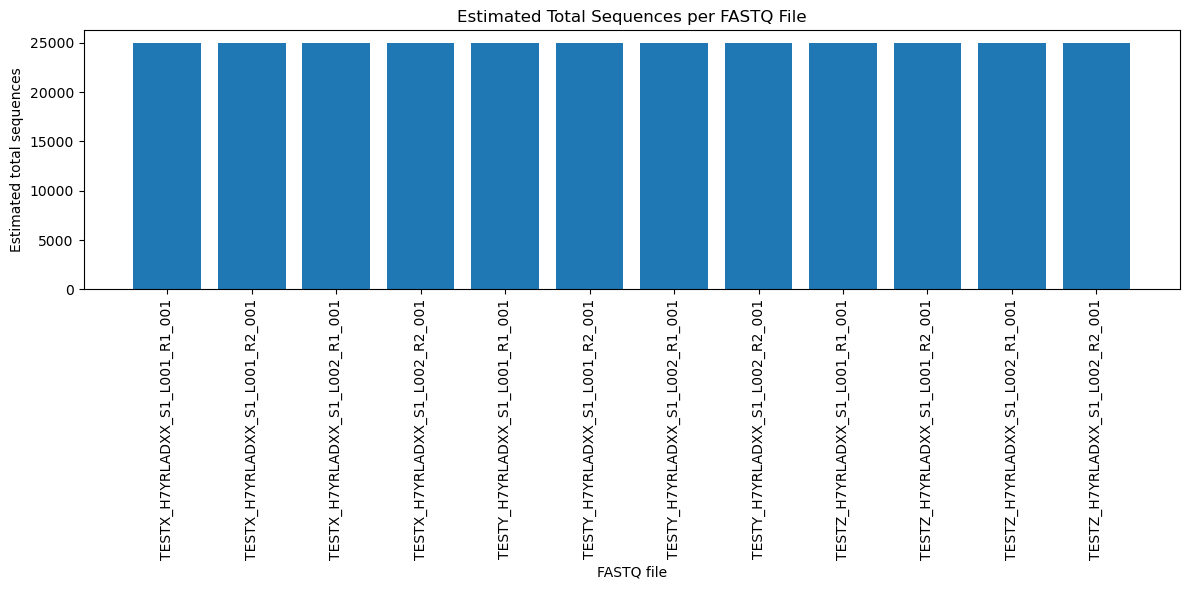

In [8]:
plt.figure(figsize=(12, 6))
plt.bar(qc_clean["Sample"], qc_clean["estimated_total_sequences"])
plt.xticks(rotation=90)
plt.ylabel("Estimated total sequences")
plt.xlabel("FASTQ file")
plt.title("Estimated Total Sequences per FASTQ File")
plt.tight_layout()
plt.savefig(figures_dir / "estimated_total_sequences_per_fastq.png", dpi=300, bbox_inches="tight")
plt.show()

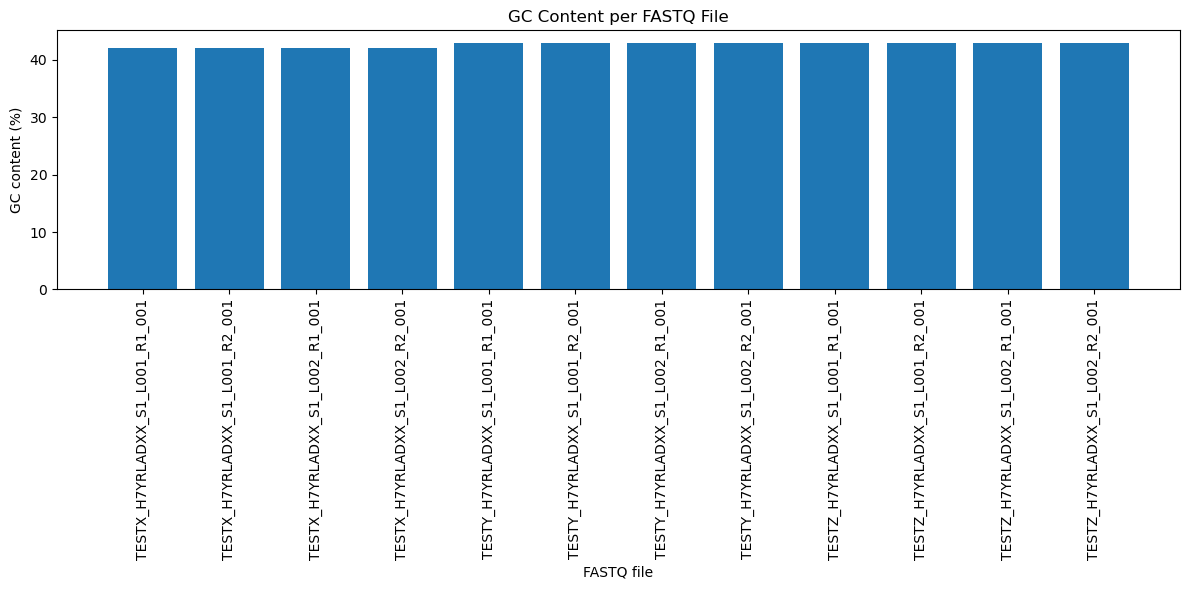

In [9]:
plt.figure(figsize=(12, 6))
plt.bar(qc_clean["Sample"], qc_clean["percent_gc"])
plt.xticks(rotation=90)
plt.ylabel("GC content (%)")
plt.xlabel("FASTQ file")
plt.title("GC Content per FASTQ File")
plt.tight_layout()
plt.savefig(figures_dir / "gc_content_per_fastq.png", dpi=300, bbox_inches="tight")
plt.show()

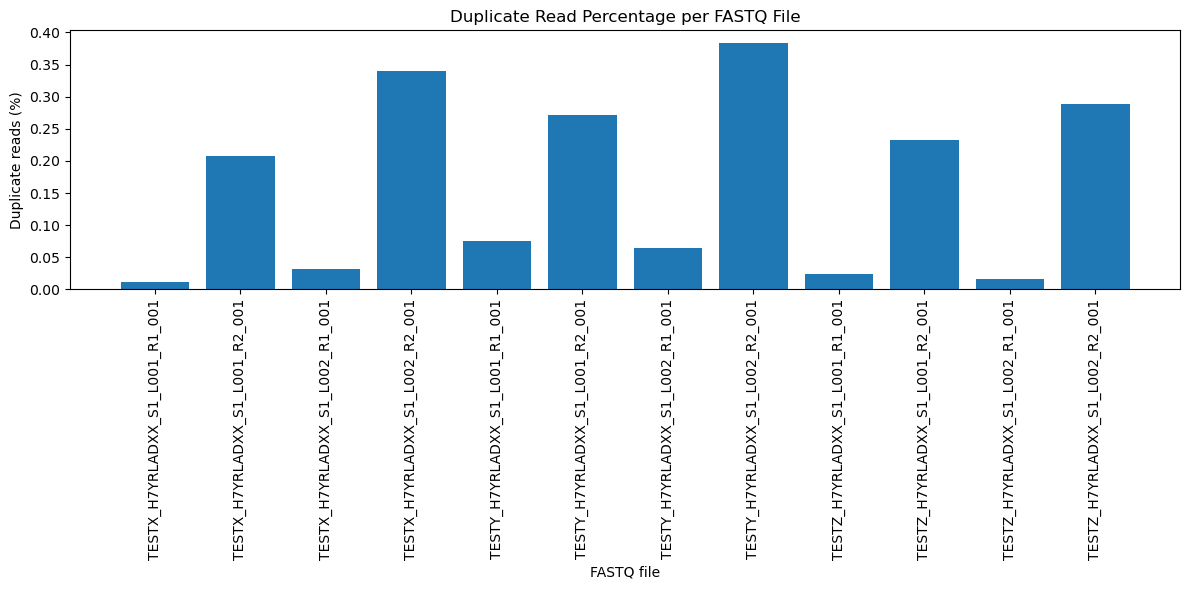

In [10]:
plt.figure(figsize=(12, 6))
plt.bar(qc_clean["Sample"], qc_clean["percent_duplicates"])
plt.xticks(rotation=90)
plt.ylabel("Duplicate reads (%)")
plt.xlabel("FASTQ file")
plt.title("Duplicate Read Percentage per FASTQ File")
plt.tight_layout()
plt.savefig(figures_dir / "duplicate_percentage_per_fastq.png", dpi=300, bbox_inches="tight")
plt.show()

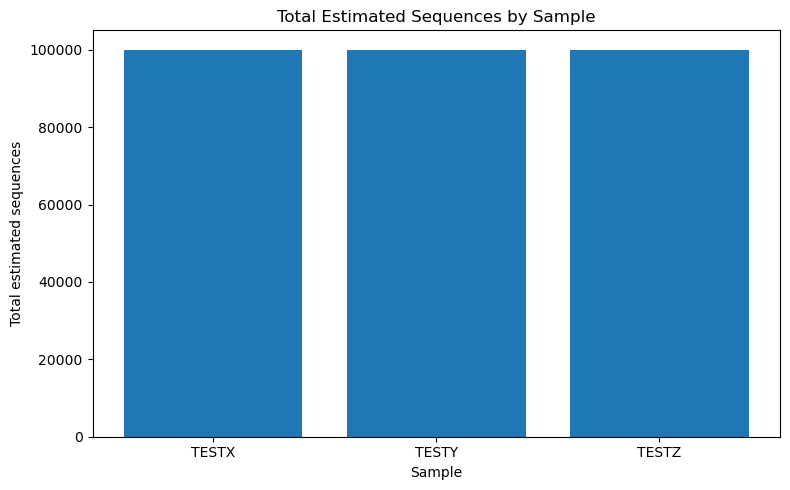

In [11]:
plt.figure(figsize=(8, 5))
plt.bar(sample_summary["sample_id"], sample_summary["total_estimated_sequences"])
plt.ylabel("Total estimated sequences")
plt.xlabel("Sample")
plt.title("Total Estimated Sequences by Sample")
plt.tight_layout()
plt.savefig(figures_dir / "total_estimated_sequences_by_sample.png", dpi=300, bbox_inches="tight")
plt.show()

## FastQC Module Status Summary

FastQC evaluates each FASTQ file across multiple quality-control modules and assigns module-level statuses such as pass, warn, or fail.

This section parses the MultiQC FastQC status heatmap table to summarize warning and failure patterns across samples. This provides a dashboard-style overview of which QC modules may require closer review.

In [12]:
# Load FastQC module status table generated by MultiQC
fastqc_status = pd.read_csv(fastqc_status_path, sep="\t")

fastqc_status.head()

,.,Basic Statistics,Per Base Sequence Quality,Per Tile Sequence Quality,Per Sequence Quality Scores,Per Base Sequence Content,Per Sequence GC Content,Per Base N Content,Sequence Length Distribution,Sequence Duplication Levels,Overrepresented Sequences,Adapter Content
0,TESTX_H7YRLADXX_S1_L001_R1_001,1,1,1,1,0.25,0.5,0.25,1,1,1.0,1
1,TESTX_H7YRLADXX_S1_L001_R2_001,1,1,1,1,0.25,0.5,0.25,1,1,0.5,1
2,TESTX_H7YRLADXX_S1_L002_R1_001,1,1,1,1,0.25,0.5,0.25,1,1,1.0,1
3,TESTX_H7YRLADXX_S1_L002_R2_001,1,1,1,1,0.25,0.5,0.25,1,1,0.5,1
4,TESTY_H7YRLADXX_S1_L001_R1_001,1,1,1,1,0.25,0.5,0.25,1,1,1.0,1


In [13]:
fastqc_status.shape, fastqc_status.columns.tolist()

((12, 12),
 ['.',
  'Basic Statistics',
  'Per Base Sequence Quality',
  'Per Tile Sequence Quality',
  'Per Sequence Quality Scores',
  'Per Base Sequence Content',
  'Per Sequence GC Content',
  'Per Base N Content',
  'Sequence Length Distribution',
  'Sequence Duplication Levels',
  'Overrepresented Sequences',
  'Adapter Content'])

In [14]:
# Rename first column to Sample if needed
if fastqc_status.columns[0] != "Sample":
    fastqc_status = fastqc_status.rename(columns={fastqc_status.columns[0]: "Sample"})

# Preview cleaned status table
fastqc_status.head()

,Sample,Basic Statistics,Per Base Sequence Quality,Per Tile Sequence Quality,Per Sequence Quality Scores,Per Base Sequence Content,Per Sequence GC Content,Per Base N Content,Sequence Length Distribution,Sequence Duplication Levels,Overrepresented Sequences,Adapter Content
0,TESTX_H7YRLADXX_S1_L001_R1_001,1,1,1,1,0.25,0.5,0.25,1,1,1.0,1
1,TESTX_H7YRLADXX_S1_L001_R2_001,1,1,1,1,0.25,0.5,0.25,1,1,0.5,1
2,TESTX_H7YRLADXX_S1_L002_R1_001,1,1,1,1,0.25,0.5,0.25,1,1,1.0,1
3,TESTX_H7YRLADXX_S1_L002_R2_001,1,1,1,1,0.25,0.5,0.25,1,1,0.5,1
4,TESTY_H7YRLADXX_S1_L001_R1_001,1,1,1,1,0.25,0.5,0.25,1,1,1.0,1


In [15]:
# The MultiQC FastQC status heatmap file is already numeric.
# Interpret scores as:
# 1.00 = pass
# 0.50 = warn
# 0.25 = fail

status_columns = [col for col in fastqc_status.columns if col != "Sample"]

fastqc_status_numeric = fastqc_status.copy()

for col in status_columns:
    fastqc_status_numeric[col] = pd.to_numeric(
        fastqc_status_numeric[col],
        errors="coerce"
    )

fastqc_status_numeric.head()

,Sample,Basic Statistics,Per Base Sequence Quality,Per Tile Sequence Quality,Per Sequence Quality Scores,Per Base Sequence Content,Per Sequence GC Content,Per Base N Content,Sequence Length Distribution,Sequence Duplication Levels,Overrepresented Sequences,Adapter Content
0,TESTX_H7YRLADXX_S1_L001_R1_001,1,1,1,1,0.25,0.5,0.25,1,1,1.0,1
1,TESTX_H7YRLADXX_S1_L001_R2_001,1,1,1,1,0.25,0.5,0.25,1,1,0.5,1
2,TESTX_H7YRLADXX_S1_L002_R1_001,1,1,1,1,0.25,0.5,0.25,1,1,1.0,1
3,TESTX_H7YRLADXX_S1_L002_R2_001,1,1,1,1,0.25,0.5,0.25,1,1,0.5,1
4,TESTY_H7YRLADXX_S1_L001_R1_001,1,1,1,1,0.25,0.5,0.25,1,1,1.0,1


In [16]:
fastqc_status_numeric["sample_id"] = fastqc_status_numeric["Sample"].str.extract(r"^(TEST[XYZ])")
fastqc_status_numeric["lane"] = fastqc_status_numeric["Sample"].str.extract(r"_(L00[12])_")
fastqc_status_numeric["read"] = fastqc_status_numeric["Sample"].str.extract(r"_(R[12])_")

fastqc_status_summary = fastqc_status_numeric[["Sample", "sample_id", "lane", "read"]].copy()

fastqc_status_summary["n_pass_modules"] = (
    fastqc_status_numeric[status_columns] == 1
).sum(axis=1)

fastqc_status_summary["n_warn_modules"] = (
    fastqc_status_numeric[status_columns] == 0.5
).sum(axis=1)

fastqc_status_summary["n_fail_modules"] = (
    fastqc_status_numeric[status_columns] <= 0.25
).sum(axis=1)

fastqc_status_summary["total_modules"] = len(status_columns)

fastqc_status_summary

,Sample,sample_id,lane,read,n_pass_modules,n_warn_modules,n_fail_modules,total_modules
0,TESTX_H7YRLADXX_S1_L001_R1_001,TESTX,L001,R1,8,1,2,11
1,TESTX_H7YRLADXX_S1_L001_R2_001,TESTX,L001,R2,7,2,2,11
2,TESTX_H7YRLADXX_S1_L002_R1_001,TESTX,L002,R1,8,1,2,11
3,TESTX_H7YRLADXX_S1_L002_R2_001,TESTX,L002,R2,7,2,2,11
4,TESTY_H7YRLADXX_S1_L001_R1_001,TESTY,L001,R1,8,1,2,11
5,TESTY_H7YRLADXX_S1_L001_R2_001,TESTY,L001,R2,7,2,2,11
6,TESTY_H7YRLADXX_S1_L002_R1_001,TESTY,L002,R1,8,1,2,11
7,TESTY_H7YRLADXX_S1_L002_R2_001,TESTY,L002,R2,7,2,2,11
8,TESTZ_H7YRLADXX_S1_L001_R1_001,TESTZ,L001,R1,8,1,2,11
9,TESTZ_H7YRLADXX_S1_L001_R2_001,TESTZ,L001,R2,7,2,2,11


In [17]:
sample_module_summary = (
    fastqc_status_summary
    .groupby("sample_id")
    .agg(
        n_fastq_files=("Sample", "count"),
        total_pass_modules=("n_pass_modules", "sum"),
        total_warn_modules=("n_warn_modules", "sum"),
        total_fail_modules=("n_fail_modules", "sum"),
        mean_warn_modules_per_fastq=("n_warn_modules", "mean"),
        mean_fail_modules_per_fastq=("n_fail_modules", "mean"),
    )
    .reset_index()
)

sample_module_summary

,sample_id,n_fastq_files,total_pass_modules,total_warn_modules,total_fail_modules,mean_warn_modules_per_fastq,mean_fail_modules_per_fastq
0,TESTX,4,30,6,8,1.5,2.0
1,TESTY,4,30,6,8,1.5,2.0
2,TESTZ,4,30,6,8,1.5,2.0


In [18]:
module_summary = []

for module in status_columns:
    module_summary.append(
        {
            "module": module,
            "pass_count": (fastqc_status_numeric[module] == 1).sum(),
            "warn_count": (fastqc_status_numeric[module] == 0.5).sum(),
            "fail_count": (fastqc_status_numeric[module] <= 0.25).sum(),
        }
    )

module_summary = pd.DataFrame(module_summary)

module_summary["total_flags"] = (
    module_summary["warn_count"] + module_summary["fail_count"]
)

module_summary = module_summary.sort_values(
    ["fail_count", "warn_count"],
    ascending=False
)

module_summary

,module,pass_count,warn_count,fail_count,total_flags
4,Per Base Sequence Content,0,0,12,12
6,Per Base N Content,0,0,12,12
5,Per Sequence GC Content,0,12,0,12
9,Overrepresented Sequences,6,6,0,6
0,Basic Statistics,12,0,0,0
1,Per Base Sequence Quality,12,0,0,0
2,Per Tile Sequence Quality,12,0,0,0
3,Per Sequence Quality Scores,12,0,0,0
7,Sequence Length Distribution,12,0,0,0
8,Sequence Duplication Levels,12,0,0,0


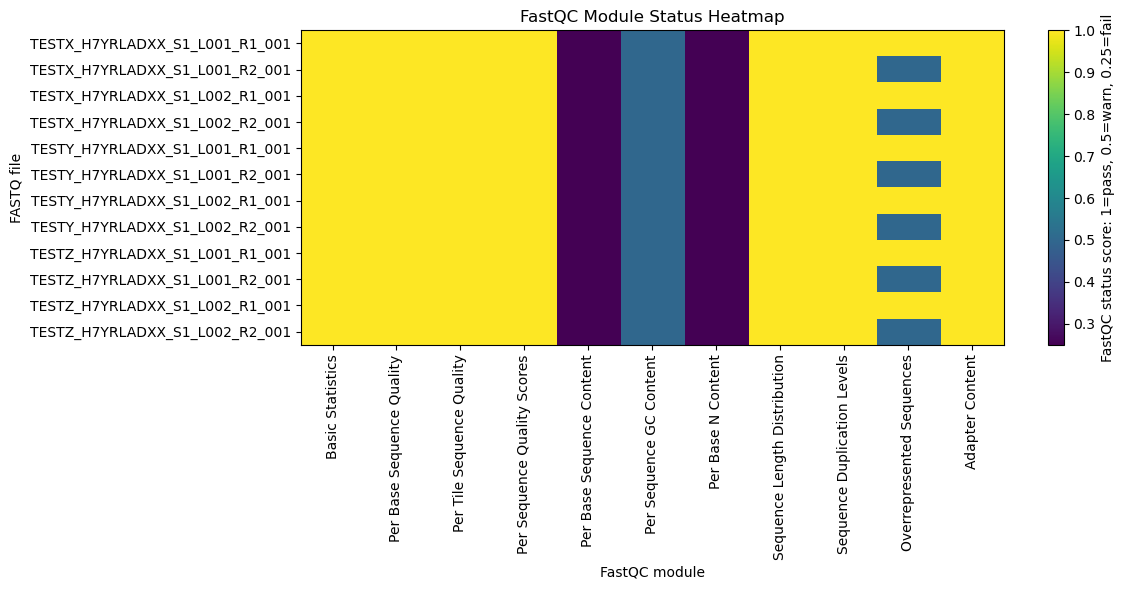

In [19]:
# Prepare numeric matrix for heatmap
heatmap_data = fastqc_status_numeric.set_index("Sample")[status_columns]

plt.figure(figsize=(12, 6))

# Create heatmap and store it as an object
heatmap = plt.imshow(heatmap_data, aspect="auto")

plt.yticks(range(len(heatmap_data.index)), heatmap_data.index)
plt.xticks(range(len(heatmap_data.columns)), heatmap_data.columns, rotation=90)

# Attach colorbar to the heatmap object
plt.colorbar(
    heatmap,
    label="FastQC status score: 1=pass, 0.5=warn, 0.25=fail"
)

plt.title("FastQC Module Status Heatmap")
plt.xlabel("FastQC module")
plt.ylabel("FASTQ file")
plt.tight_layout()

plt.savefig(
    figures_dir / "fastqc_module_status_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Interpretation of FastQC Module Status

The FastQC module status heatmap summarizes which QC modules passed, warned, or failed across each FASTQ file.

In this dataset, the most important interpretation is not whether every module passes, but whether there are consistent warning or failure patterns across samples, lanes, or read directions. Repeated failures across all files may reflect expected properties of the test dataset or sequencing design, while failures isolated to one file may indicate a sample- or lane-specific QC issue.

Because this project uses small public test FASTQ files, these results are interpreted as a workflow demonstration rather than a biological or clinical QC assessment.

## Final QC Flag Table

A simple rule-based QC flag table was created to summarize whether each FASTQ file should be considered acceptable, review-needed, or potentially problematic based on duplicate rate, GC content, and FastQC module failures.

These thresholds are intentionally educational and should not be interpreted as clinical laboratory QC thresholds.

In [20]:
def assign_qc_flag(row):
    if row["n_fail_modules"] >= 3:
        return "Review - multiple failed FastQC modules"
    elif row["percent_duplicates"] > 50:
        return "Review - high duplication"
    elif row["percent_gc"] < 35 or row["percent_gc"] > 65:
        return "Review - unusual GC content"
    elif row["n_fail_modules"] >= 1:
        return "Review - FastQC module failure present"
    elif row["n_warn_modules"] >= 3:
        return "Monitor - multiple FastQC warnings"
    else:
        return "Pass - no major QC concerns"


qc_dashboard = qc_clean.merge(
    fastqc_status_summary[
        ["Sample", "n_pass_modules", "n_warn_modules", "n_fail_modules", "total_modules"]
    ],
    on="Sample",
    how="left"
)

qc_dashboard["QC_Flag"] = qc_dashboard.apply(assign_qc_flag, axis=1)

qc_dashboard[
    [
        "Sample",
        "sample_id",
        "lane",
        "read",
        "estimated_total_sequences",
        "percent_gc",
        "percent_duplicates",
        "percent_fails",
        "n_warn_modules",
        "n_fail_modules",
        "QC_Flag",
    ]
]

,Sample,sample_id,lane,read,estimated_total_sequences,percent_gc,percent_duplicates,percent_fails,n_warn_modules,n_fail_modules,QC_Flag
0,TESTX_H7YRLADXX_S1_L001_R1_001,TESTX,L001,R1,25000,42.0,0.012,18.181818,1,2,Review - FastQC module failure present
1,TESTX_H7YRLADXX_S1_L001_R2_001,TESTX,L001,R2,25000,42.0,0.208,18.181818,2,2,Review - FastQC module failure present
2,TESTX_H7YRLADXX_S1_L002_R1_001,TESTX,L002,R1,25000,42.0,0.032,18.181818,1,2,Review - FastQC module failure present
3,TESTX_H7YRLADXX_S1_L002_R2_001,TESTX,L002,R2,25000,42.0,0.340,18.181818,2,2,Review - FastQC module failure present
4,TESTY_H7YRLADXX_S1_L001_R1_001,TESTY,L001,R1,25000,43.0,0.076,18.181818,1,2,Review - FastQC module failure present
5,TESTY_H7YRLADXX_S1_L001_R2_001,TESTY,L001,R2,25000,43.0,0.272,18.181818,2,2,Review - FastQC module failure present
6,TESTY_H7YRLADXX_S1_L002_R1_001,TESTY,L002,R1,25000,43.0,0.064,18.181818,1,2,Review - FastQC module failure present
7,TESTY_H7YRLADXX_S1_L002_R2_001,TESTY,L002,R2,25000,43.0,0.384,18.181818,2,2,Review - FastQC module failure present
8,TESTZ_H7YRLADXX_S1_L001_R1_001,TESTZ,L001,R1,25000,43.0,0.024,18.181818,1,2,Review - FastQC module failure present
9,TESTZ_H7YRLADXX_S1_L001_R2_001,TESTZ,L001,R2,25000,43.0,0.232,18.181818,2,2,Review - FastQC module failure present


In [21]:
qc_flag_summary = (
    qc_dashboard["QC_Flag"]
    .value_counts()
    .rename_axis("QC_Flag")
    .reset_index(name="FASTQ_File_Count")
)

qc_flag_summary

,QC_Flag,FASTQ_File_Count
0,Review - FastQC module failure present,12


In [22]:
qc_dashboard.to_csv(
    summary_tables_dir / "ngs_qc_dashboard_fastq_level_flags.csv",
    index=False
)

qc_flag_summary.to_csv(
    summary_tables_dir / "ngs_qc_dashboard_flag_summary.csv",
    index=False
)

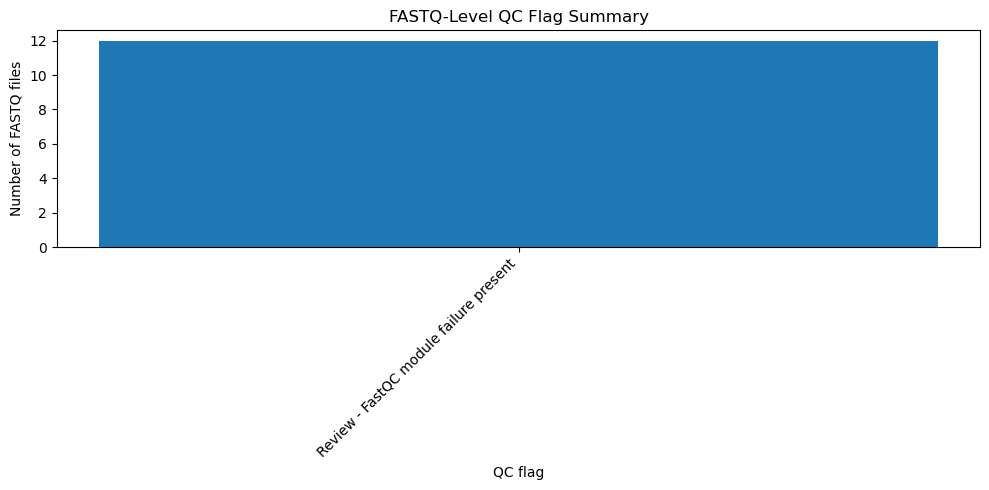

In [23]:
plt.figure(figsize=(10, 5))
plt.bar(qc_flag_summary["QC_Flag"], qc_flag_summary["FASTQ_File_Count"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of FASTQ files")
plt.xlabel("QC flag")
plt.title("FASTQ-Level QC Flag Summary")
plt.tight_layout()

plt.savefig(
    figures_dir / "fastq_level_qc_flag_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Dataset Limitation: Low QC Variation Across Test Samples

The QC plots show limited separation across samples because the dataset is a small public test dataset with highly similar sequencing characteristics. Each biological sample contains four FASTQ files, with similar read counts, read length, GC content, duplication rate, and FastQC failure percentage.

As a result, the plots are most useful for demonstrating the structure of a reproducible QC dashboard workflow rather than identifying major sample-specific QC problems.

In a production NGS workflow, the same dashboard would be more informative when applied to a larger cohort containing variable read depth, library quality, GC content, duplication rates, adapter content, or sample-specific FastQC failures.

## Project Summary

This notebook demonstrates a reproducible NGS quality-control dashboard workflow using public paired-end FASTQ test data.

The workflow included command-line FastQC analysis, MultiQC aggregation, Python-based parsing of MultiQC output tables, FASTQ-level and sample-level QC summaries, visualization, and dashboard-style interpretation.

Across the 12 FASTQ files, the dashboard summarized read counts, GC content, sequence length, duplication rate, FastQC failure percentage, and sample-level QC consistency.

Because the public test dataset is highly uniform, this notebook is best interpreted as a workflow demonstration. A companion notebook can later extend the dashboard using mixed-quality or intentionally modified FASTQ files to show stronger QC contrasts.

This project is intended for educational and portfolio purposes only. The QC summaries are not clinical laboratory thresholds and should not be used for clinical sample acceptance or reporting decisions.